# 📊 Stock Market Analysis & Portfolio Optimization Project

## Project Overview

This is a **complete financial analytics suite** with two complementary interfaces:

### 1️⃣ **Interactive Streamlit Web App** (`app.py`)
- 🎨 **Production-grade dark mode** enforced (locked via `.streamlit/config.toml`)
- 📌 **Dynamic stock selection** with elegant **badge-style display** (auto-wrapping for many stocks)
- 📈 Real-time analysis: price charts, risk metrics, portfolio optimization, sector allocation
- 🔄 Multiple tabs: Market Overview, Risk Analytics, Portfolio Optimization, Investment Growth
- ⚡ Cached computations for fast performance
- **Run with:** `streamlit run app.py`

### 2️⃣ **Standalone Jupyter Notebook** (This file - `notebook_analysis.ipynb`)
- 📓 **End-to-end financial analysis** pipeline for research and reproducibility
- 🔧 Fully customizable ticker list (change at the top of cell 2)
- 📊 Step-by-step exploration: data → EDA → trend → returns → risk → optimization
- ✍️ Educational & analytical commentary
- **Run in:** Jupyter, VS Code, or any notebook environment

---

## Quick Start: Choose Your Tool

| Feature | Streamlit App | Jupyter Notebook |
|---------|---------------|------------------|
| **Interface** | Interactive web dashboard | Static/exploratory |
| **Customization** | Sidebar controls | Code cells |
| **Real-time** | ✅ Live data fetch | Manual refresh |
| **Sharing** | Deploy to Streamlit Cloud | Export as HTML/PDF |
| **Use case** | Daily monitoring, presentations | Research, tutorials |

**This notebook is ideal for:**
- Deep-dive analysis on specific tickers
- Learning the financial concepts step-by-step
- Reproducible research and documentation
- Exporting results for reports

---

# 📓 Notebook: Stock Market Analysis & Portfolio Optimization

## Dynamic Financial Analytics with Modern Portfolio Theory

This notebook performs **end-to-end financial analysis** on **user-selected stocks**. Analyze **any valid ticker** (Indian NSE/BSE or global markets) by simply changing the `tickers` list at the top.

### What You'll Learn in This Notebook

- **Stock market data**: How to download, clean, and analyze OHLCV price data
- **Trend & volatility**: Moving averages, drawdowns, rolling metrics
- **Modern Portfolio Theory (MPT)**: Diversification, efficient frontier, optimal weights
- **Risk metrics**: Sharpe ratio, Sortino ratio, VaR, Beta, maximum drawdown
- **Portfolio optimization**: Monte Carlo simulation (10,000 portfolios) to find max-Sharpe and min-volatility allocations
- **Investment simulation**: Compare buy-and-hold vs optimized portfolio growth

### How to Use This Notebook

1. **Modify `tickers`** in cell 2 to analyze any stocks you want
2. **Run all cells** sequentially (Ctrl+A → Ctrl+Enter in most notebooks)
3. **Charts and metrics** update automatically for your selection
4. **Export** as PDF/HTML for sharing results

### Dynamic Stock Selection Examples

- Indian: `RELIANCE.NS`, `TCS.NS`, `INFY.NS`, `HDFCBANK.NS`, `^NSEI` (Nifty 50 Index)
- US: `AAPL`, `MSFT`, `GOOGL`, `^GSPC` (S&P 500 Index)
- Mix and match indices with individual stocks for sector comparison


In [26]:
# =============================================================================
# USER-DEFINED STOCK LIST — Modify this to analyze ANY valid ticker
# =============================================================================
# Examples: Indian (RELIANCE.NS, TCS.NS), US (AAPL, MSFT), Indices (^NSEI, ^GSPC)
tickers = ['RELIANCE.NS', 'TCS.NS', '^NSEI']

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# 5 years of data
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)
print(f"Tickers: {tickers}")
print(f"Date range: {start_date.date()} to {end_date.date()}")

Tickers: ['RELIANCE.NS', 'TCS.NS', '^NSEI']
Date range: 2021-03-12 to 2026-03-11


---
## 2️⃣ Data Collection

We download **5 years of daily OHLCV data** using Yahoo Finance.

- **OHLC**: Open, High, Low, Close — the four main price points for each day
- **Adjusted Close**: Close price adjusted for splits, dividends, and other corporate actions. Use this for return calculations so historical comparisons are accurate.

In [27]:
# Download multiple tickers at once (yf.download returns MultiIndex columns)
raw = yf.download(tickers, start=start_date, end=end_date, progress=True, auto_adjust=False, group_by='ticker')

# If single ticker, yfinance returns different structure — normalize to MultiIndex
if len(tickers) == 1:
    raw.columns = pd.MultiIndex.from_product([[tickers[0]], raw.columns])
raw.head(10)

[*********************100%***********************]  3 of 3 completed


Ticker             ^NSEI                                            \
Price               Open          High           Low         Close   
Date                                                                 
2021-03-12  15321.150391  15336.299805  14953.599609  15030.950195   
2021-03-15  15048.400391  15048.400391  14745.849609  14929.500000   
2021-03-16  14996.099609  15051.599609  14890.650391  14910.450195   
2021-03-17  14946.549805  14956.549805  14696.049805  14721.299805   
2021-03-18  14855.500000  14875.200195  14478.599609  14557.849609   
2021-03-19  14471.150391  14788.250000  14350.099609  14744.000000   
2021-03-22  14736.299805  14763.900391  14597.849609  14736.400391   
2021-03-23  14768.549805  14878.599609  14707.000000  14814.750000   
2021-03-24  14712.450195  14752.349609  14535.000000  14549.400391   
2021-03-25  14570.900391  14575.599609  14264.400391  14324.900391   

Ticker                                   TCS.NS                            \
Price          Adj Close    Volume         Open         High          Low   
Date                                                                        
2021-03-12  15030.950195  493200.0  3075.000000  3117.000000  3041.350098   
2021-03-15  14929.500000  467500.0  3041.000000  3099.000000  3041.000000   
2021-03-16  14910.450195     100.0  3060.000000  3141.000000  3060.000000   
2021-03-17  14721.299805     100.0  3105.000000  3155.000000  3085.300049   
2021-03-18  14557.849609  542200.0  3125.949951  3146.449951  2987.050049   
2021-03-19  14744.000000  919200.0  3030.000000  3099.000000  3005.000000   
2021-03-22  14736.400391  459000.0  3048.699951  3139.449951  3018.649902   
2021-03-23  14814.750000  474200.0  3140.000000  3169.000000  3122.850098   
2021-03-24  14549.400391  456400.0  3111.199951  3152.300049  3111.149902   
2021-03-25  14324.900391  606800.0  3112.199951  3130.850098  3050.000000   

Ticker                                         RELIANCE.NS               \
Price             Close    Adj Close   Volume         Open         High   
Date                                                                      
2021-03-12  3057.949951  2688.173340  2938317  1012.992126  1018.253235   
2021-03-15  3066.149902  2695.381348  3097083   987.632751   991.716980   
2021-03-16  3110.050049  2733.973145  4894756   975.610657   981.148682   
2021-03-17  3112.949951  2736.522949  3838390   968.249756   970.534180   
2021-03-18  3036.500000  2669.317383  3656306   956.643005   962.134888   
2021-03-19  3050.199951  2681.360596  5776626   918.846191   967.234436   
2021-03-22  3129.649902  2751.203125  2821646   955.766174   957.150635   
2021-03-23  3142.600098  2762.586914  3305973   951.589600   973.626221   
2021-03-24  3121.100098  2743.687012  2207104   959.804260   959.804260   
2021-03-25  3064.850098  2694.238281  3179786   947.920654   947.920654   

Ticker                                                    
Price              Low       Close   Adj Close    Volume  
Date                                                      
2021-03-12  980.179504  986.502075  969.254700  16864952  
2021-03-15  960.150391  973.257019  956.241211  16698099  
2021-03-16  967.072937  969.426575  952.477722  13873801  
2021-03-17  939.198303  948.543701  931.960022  19210236  
2021-03-18  923.461182  927.199341  910.988770  20647480  
2021-03-19  915.061890  960.842651  944.043884  41787429  
2021-03-22  938.321472  951.797241  935.156555  18572478  
2021-03-23  948.843689  963.380920  946.537720  17421165  
2021-03-24  941.644287  944.828613  928.309753  16822814  
2021-03-25  916.077148  919.053833  902.985718  22001648

---
## 3️⃣ Data Cleaning

- Extract **Adj Close** for each ticker
- Rename columns to ticker names
- Handle missing values (forward fill then drop remaining)
- Combine into one clean dataframe

In [28]:
# Extract Adjusted Close (use 'Adj Close' or 'Close' if Adj not available)
def get_adj_close(raw_df, ticker_list):
    out = pd.DataFrame(index=raw_df.index)
    for t in ticker_list:
        if isinstance(raw_df.columns, pd.MultiIndex):
            if (t, 'Adj Close') in raw_df.columns:
                out[t] = raw_df[(t, 'Adj Close')]
            elif (t, 'Close') in raw_df.columns:
                out[t] = raw_df[(t, 'Close')]
            else:
                out[t] = raw_df[t]['Adj Close'] if t in raw_df.columns.get_level_values(0) else raw_df[t]
        else:
            out[t] = raw_df['Adj Close'] if 'Adj Close' in raw_df.columns else raw_df['Close']
    return out

df = get_adj_close(raw, tickers)
df = df.ffill().bfill().dropna(how='all')
df.head()

,RELIANCE.NS,TCS.NS,^NSEI
Date,,,
2021-03-12,969.254700,2688.173340,15030.950195
2021-03-15,956.241211,2695.381348,14929.500000
2021-03-16,952.477722,2733.973145,14910.450195
2021-03-17,931.960022,2736.522949,14721.299805
2021-03-18,910.988770,2669.317383,14557.849609


---
## 4️⃣ Exploratory Data Analysis

Basic stats: `head()`, `info()`, `describe()`, and **correlation matrix** to see how selected stocks move together.

In [29]:
print("Shape:", df.shape)
df.head(10)

Shape: (1236, 3)


,RELIANCE.NS,TCS.NS,^NSEI
Date,,,
2021-03-12,969.254700,2688.173340,15030.950195
2021-03-15,956.241211,2695.381348,14929.500000
2021-03-16,952.477722,2733.973145,14910.450195
2021-03-17,931.960022,2736.522949,14721.299805
2021-03-18,910.988770,2669.317383,14557.849609
2021-03-19,944.043884,2681.360596,14744.000000
2021-03-22,935.156555,2751.203125,14736.400391
2021-03-23,946.537720,2762.586914,14814.750000
2021-03-24,928.309753,2743.687012,14549.400391


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1236 entries, 2021-03-12 to 2026-03-11
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   RELIANCE.NS  1236 non-null   float64
 1   TCS.NS       1236 non-null   float64
 2   ^NSEI        1236 non-null   float64
dtypes: float64(3)
memory usage: 38.6 KB


In [31]:
df.describe()

,RELIANCE.NS,TCS.NS,^NSEI
count,1236.000000,1236.000000,1236.000000
mean,1240.789972,3263.710641,20467.634725
std,173.080283,394.216686,3566.198403
min,862.040833,2480.000000,14296.400391
25%,1117.453949,2971.419739,17474.175293
50%,1211.681030,3168.256592,19542.875000
75%,1404.925049,3462.155334,24250.424316
max,1592.300049,4311.584961,26328.550781


Correlation matrix (daily returns):
             RELIANCE.NS  TCS.NS  ^NSEI
RELIANCE.NS        1.000   0.275  0.691
TCS.NS             0.275   1.000  0.514
^NSEI              0.691   0.514  1.000


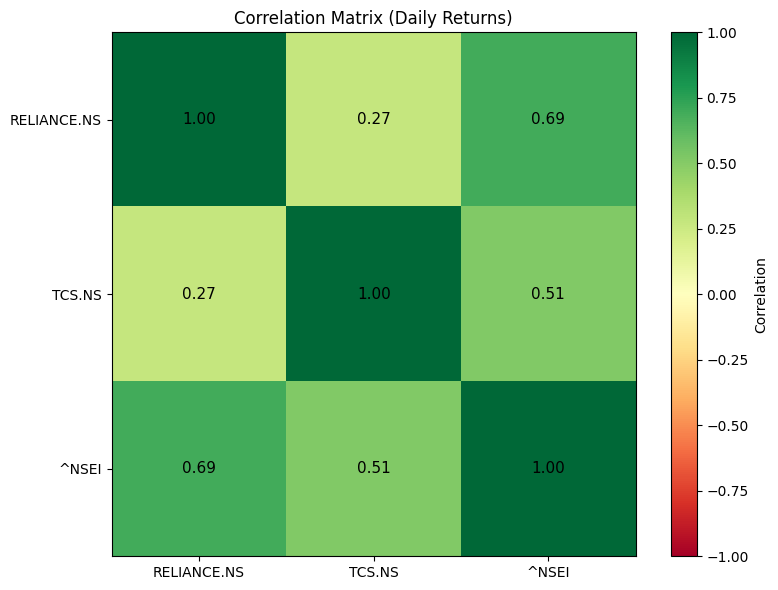

In [32]:
# Correlation matrix — how do selected stocks move together?
corr = df.pct_change().corr()
print("Correlation matrix (daily returns):")
print(corr.round(3))
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(tickers)))
ax.set_yticks(range(len(tickers)))
ax.set_xticklabels(tickers)
ax.set_yticklabels(tickers)
for i in range(len(tickers)):
    for j in range(len(tickers)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', color='black', fontsize=11)
plt.colorbar(im, ax=ax, label='Correlation')
plt.title('Correlation Matrix (Daily Returns)')
plt.tight_layout()
plt.show()

**Observations:** Check which stocks move together (positive correlation) or in opposite directions (negative). Correlations near 0 suggest diversification benefit when combined in a portfolio.

---
## 5️⃣ Trend Analysis

- **50-Day MA**: Short-term trend
- **200-Day MA**: Long-term trend
- **Golden Cross**: 50 MA crosses above 200 MA → bullish signal
- **Death Cross**: 50 MA crosses below 200 MA → bearish signal

Plots are generated **dynamically** for each selected stock.

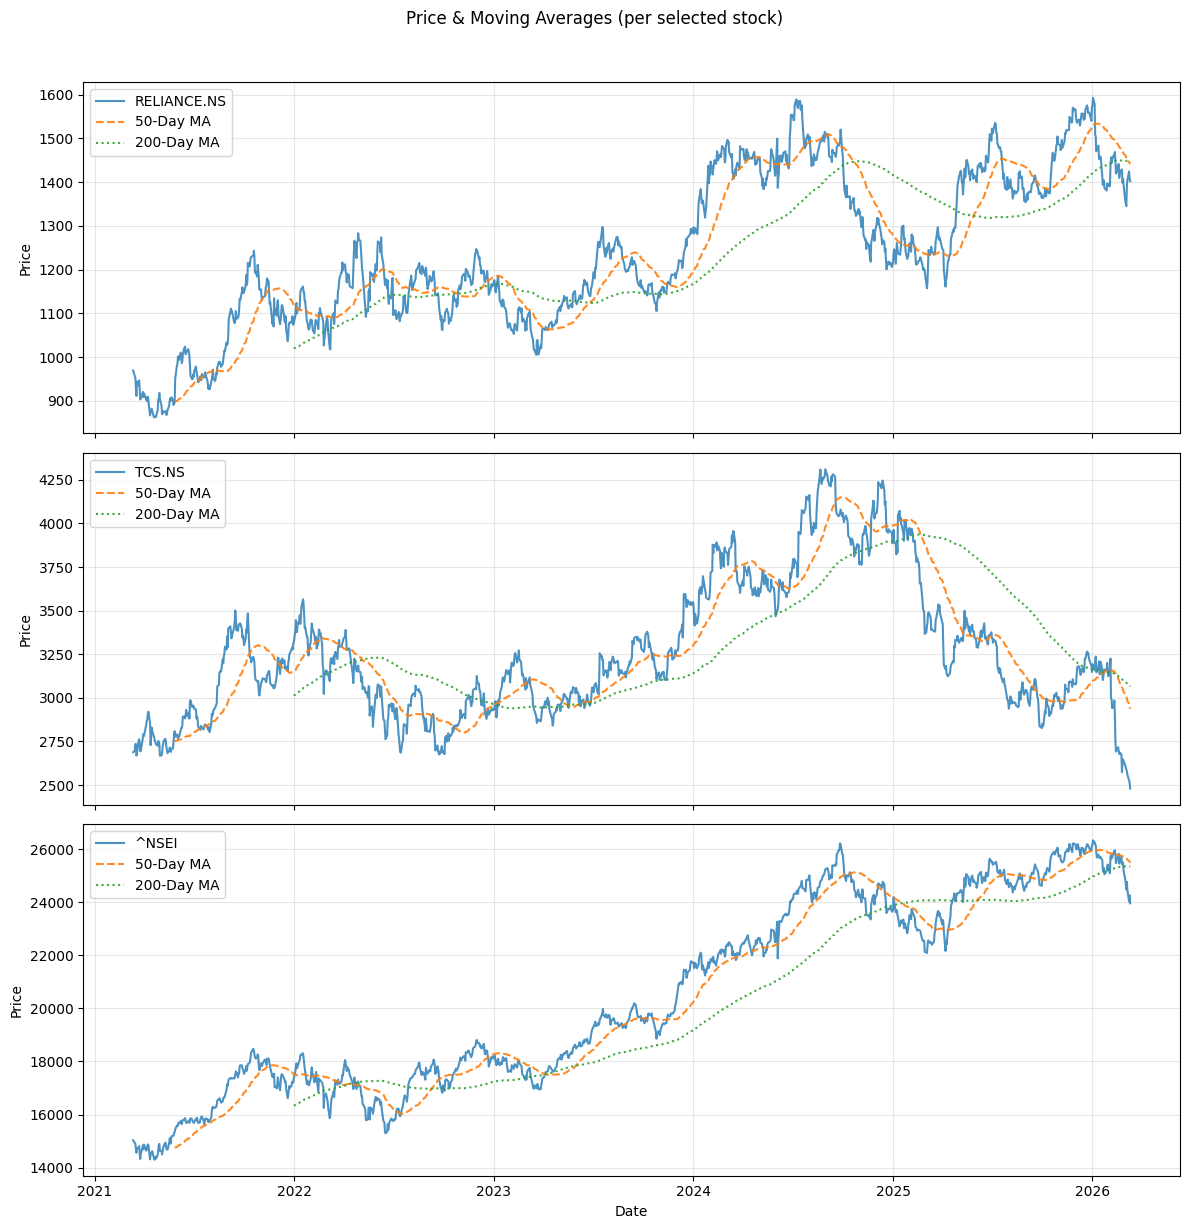

In [33]:
# Moving averages (per ticker)
MA50 = {t: df[t].rolling(50).mean() for t in tickers}
MA200 = {t: df[t].rolling(200).mean() for t in tickers}
n_stocks = len(tickers)
fig, axes = plt.subplots(n_stocks, 1, figsize=(12, 4 * n_stocks), sharex=True)
if n_stocks == 1:
    axes = [axes]
for ax, t in zip(axes, tickers):
    ax.plot(df.index, df[t], label=t, alpha=0.8)
    ax.plot(df.index, MA50[t], label='50-Day MA', linestyle='--', alpha=0.9)
    ax.plot(df.index, MA200[t], label='200-Day MA', linestyle=':', alpha=0.9)
    ax.set_ylabel('Price')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Date')
plt.suptitle('Price & Moving Averages (per selected stock)', y=1.02)
plt.tight_layout()
plt.show()

---
## 6️⃣ Returns Analysis

- **Daily returns**: `pct_change()` — day-over-day percentage change
- **Annualized return**: Mean daily return × 252 (trading days)
- **CAGR**: Compound Annual Growth Rate — geometric growth over the period

---
### Log returns (quant-style)

**Why log returns?**  
- **Mathematically correct** for compounding: log(P_t / P_{t-1}) = log(P_t) - log(P_{t-1}); multi-period log return is the sum of single-period log returns.  
- **Symmetric**: log(1.1) + log(1/1.1) = 0, whereas simple returns don't add that way.  
- **Better for models**: many quant models (e.g. volatility, VaR) assume or work better with log returns.  

We can use either; for consistency with academic/quant practice, log returns are often preferred.

In [34]:
# Log returns: ln(P_t / P_{t-1})
log_returns = np.log(df / df.shift(1)).dropna()
annual_returns_log = log_returns.mean() * 252
vol_annual_log = log_returns.std() * np.sqrt(252)
print("Annualized return (from log returns):", annual_returns_log.round(4))
print("Annualized vol (from log returns):", vol_annual_log.round(4))

Annualized return (from log returns): RELIANCE.NS    0.0753
TCS.NS        -0.0164
^NSEI          0.0951
dtype: float64
Annualized vol (from log returns): RELIANCE.NS    0.2234
TCS.NS         0.2098
^NSEI          0.1362
dtype: float64


In [35]:
daily_returns = df.pct_change().dropna()
n_years = (df.index[-1] - df.index[0]).days / 365.0
annual_returns = daily_returns.mean() * 252
# CAGR: (end/start)^(1/years) - 1
cagr = (df.iloc[-1] / df.iloc[0]) ** (1 / n_years) - 1
print("Annualized Return (mean daily * 252):")
print(annual_returns.round(4))
print("\nCAGR:")
print(cagr.round(4))

Annualized Return (mean daily * 252):
RELIANCE.NS    0.1003
TCS.NS         0.0055
^NSEI          0.1044
dtype: float64

CAGR:
RELIANCE.NS    0.0766
TCS.NS        -0.0160
^NSEI          0.0977
dtype: float64


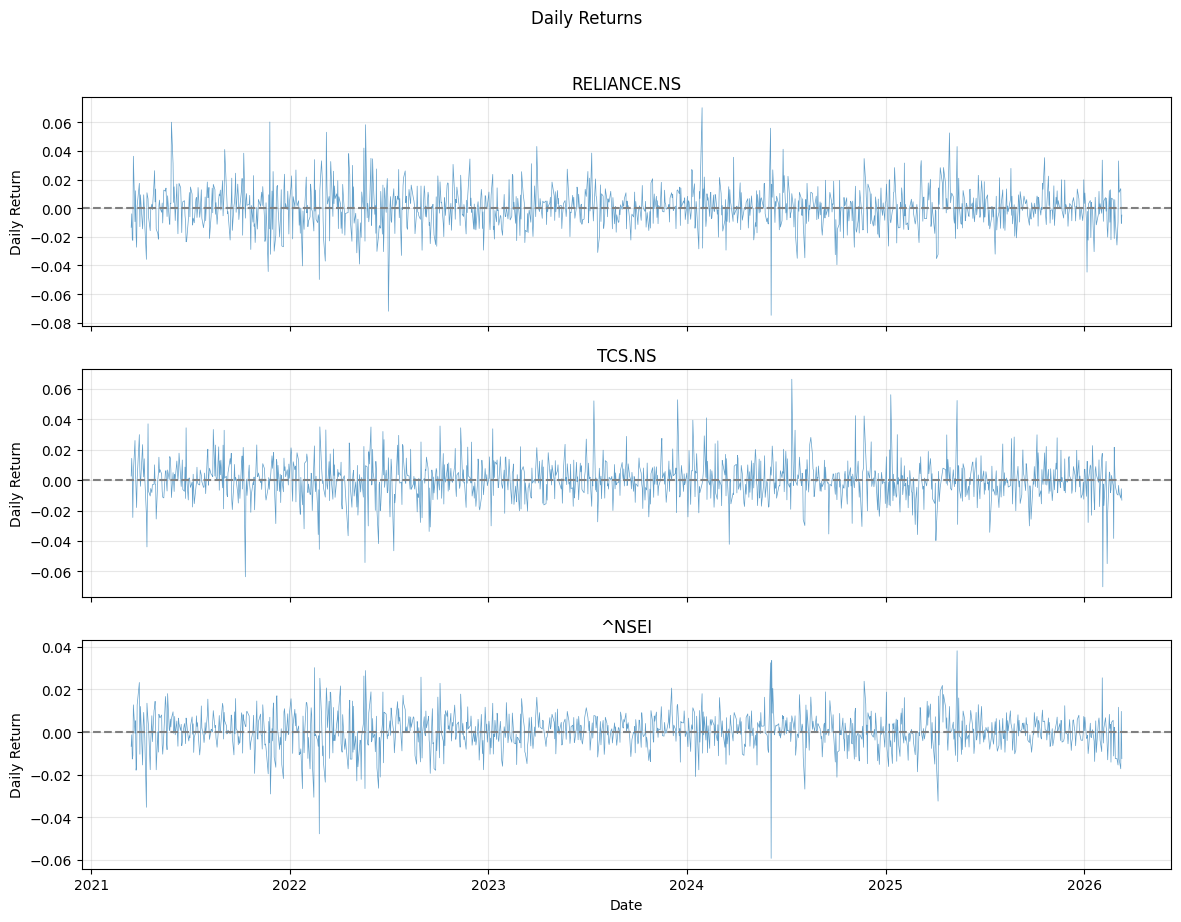

In [36]:
# Daily returns time series
fig, axes = plt.subplots(n_stocks, 1, figsize=(12, 3 * n_stocks), sharex=True)
if n_stocks == 1:
    axes = [axes]
for ax, t in zip(axes, tickers):
    ax.plot(daily_returns.index, daily_returns[t], alpha=0.7, linewidth=0.5)
    ax.axhline(0, color='gray', linestyle='--')
    ax.set_ylabel('Daily Return')
    ax.set_title(t)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Date')
plt.suptitle('Daily Returns', y=1.02)
plt.tight_layout()
plt.show()

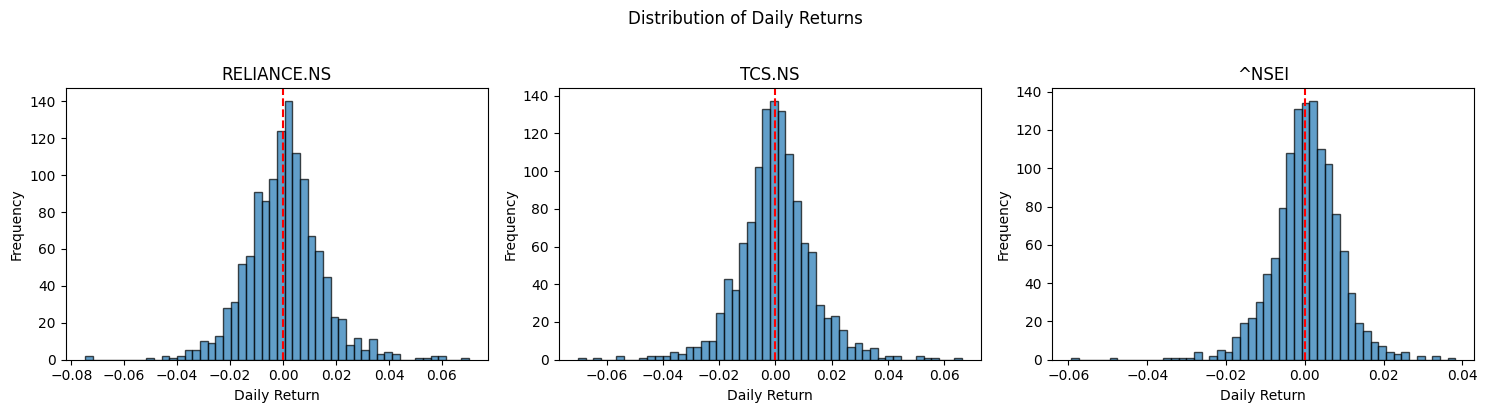

In [37]:
# Distribution of daily returns
fig, axes = plt.subplots(1, n_stocks, figsize=(5 * n_stocks, 4))
if n_stocks == 1:
    axes = [axes]
for ax, t in zip(axes, tickers):
    ax.hist(daily_returns[t].dropna(), bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--')
    ax.set_xlabel('Daily Return')
    ax.set_ylabel('Frequency')
    ax.set_title(t)
plt.suptitle('Distribution of Daily Returns', y=1.02)
plt.tight_layout()
plt.show()

---
## 7️⃣ Volatility & Risk Metrics

- **Standard deviation**: Dispersion of daily returns
- **Annualized volatility**: σ × √252 (scale to yearly)
- **Rolling 30-day volatility**: Time-varying risk
- **Maximum drawdown**: Largest peak-to-trough decline
- **Beta vs benchmark**: Sensitivity to market (benchmark = last ticker if index, else first)
- **Risk–return trade-off**: Higher return usually comes with higher volatility

In [38]:
# Volatility & risk
vol_daily = daily_returns.std()
vol_annual = vol_daily * np.sqrt(252)
rolling_vol = daily_returns.rolling(30).std() * np.sqrt(252)  # annualized rolling

def max_drawdown(series):
    cum = (1 + series).cumprod()
    running_max = cum.cummax()
    drawdown = (cum - running_max) / running_max
    return drawdown.min()

max_dd = {t: max_drawdown(daily_returns[t]) for t in tickers}
print("Annualized Volatility:")
print(vol_annual.round(4))
print("\nMaximum Drawdown:")
for t, dd in max_dd.items():
    print(f"  {t}: {dd:.2%}")

Annualized Volatility:
RELIANCE.NS    0.2236
TCS.NS         0.2097
^NSEI          0.1359
dtype: float64

Maximum Drawdown:
  RELIANCE.NS: -27.18%
  TCS.NS: -42.48%
  ^NSEI: -17.23%


---
### Value at Risk (VaR)

**VaR** answers: "What is the maximum loss (at a given confidence level) over the next period?"

- **Historical VaR (95%)**: 5th percentile of historical daily returns — no distributional assumption.  
- **Parametric VaR (95%)**: Assumes normal distribution: μ + z_{0.05} × σ (z from standard normal).  

Both are reported as daily loss (e.g. -0.02 = 2% worst-case daily loss at 95% confidence).

**Note:** If `scipy` is not installed, the cell below will auto-install it before running. This is a convenience feature for standalone notebook execution.

In [39]:
# Install scipy if not already installed (for VaR calculation)
import subprocess
import sys
try:
    from scipy import stats
except ImportError:
    print("Installing scipy...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy", "-q"])
    from scipy import stats

# Value at Risk (95% confidence level)
confidence = 0.95
var_hist = {t: np.percentile(daily_returns[t].dropna(), (1 - confidence) * 100) for t in tickers}
var_param = {t: daily_returns[t].mean() + stats.norm.ppf(1 - confidence) * daily_returns[t].std() for t in tickers}
print("Historical VaR (95%):", {t: f"{var_hist[t]:.2%}" for t in tickers})
print("Parametric VaR (95%):", {t: f"{var_param[t]:.2%}" for t in tickers})

Historical VaR (95%): {'RELIANCE.NS': '-2.13%', 'TCS.NS': '-1.98%', '^NSEI': '-1.35%'}
Parametric VaR (95%): {'RELIANCE.NS': '-2.28%', 'TCS.NS': '-2.17%', '^NSEI': '-1.37%'}


---
### Covariance matrix

Correlation shows *direction* of co-movement (-1 to 1). **Covariance** also reflects *scale* (volatility).  
Annualized covariance = Cov(daily returns) × 252. Diagonal = variances; off-diagonal = covariances. Used in portfolio optimization.

Covariance matrix (annualized):
             RELIANCE.NS    TCS.NS     ^NSEI
RELIANCE.NS     0.049999  0.012875  0.021017
TCS.NS          0.012875  0.043958  0.014657
^NSEI           0.021017  0.014657  0.018482


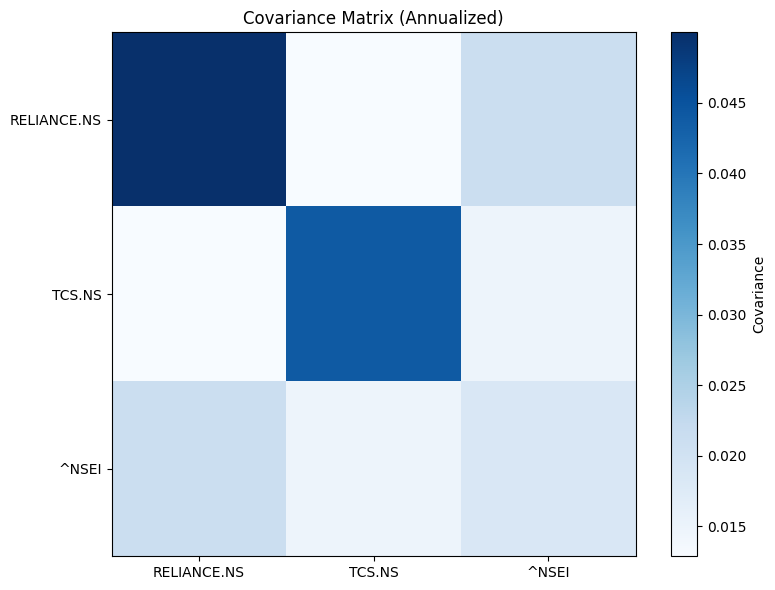

In [40]:
cov_annual = daily_returns.cov() * 252
print("Covariance matrix (annualized):")
print(cov_annual.round(6))
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cov_annual, cmap='Blues')
ax.set_xticks(range(len(tickers)))
ax.set_yticks(range(len(tickers)))
ax.set_xticklabels(tickers)
ax.set_yticklabels(tickers)
plt.colorbar(im, ax=ax, label='Covariance')
plt.title('Covariance Matrix (Annualized)')
plt.tight_layout()
plt.show()

In [41]:
# Beta vs benchmark (use last ticker as benchmark if it looks like an index, else first)
benchmark_ticker = tickers[-1]  # e.g. ^NSEI
bench_ret = daily_returns[benchmark_ticker]
cov = daily_returns.cov()
var_bench = bench_ret.var()
beta = {t: cov.loc[t, benchmark_ticker] / var_bench if t != benchmark_ticker else 1.0 for t in tickers}
print("Beta vs", benchmark_ticker, ":")
for t, b in beta.items():
    print(f"  {t}: {b:.3f}")

Beta vs ^NSEI :
  RELIANCE.NS: 1.137
  TCS.NS: 0.793
  ^NSEI: 1.000


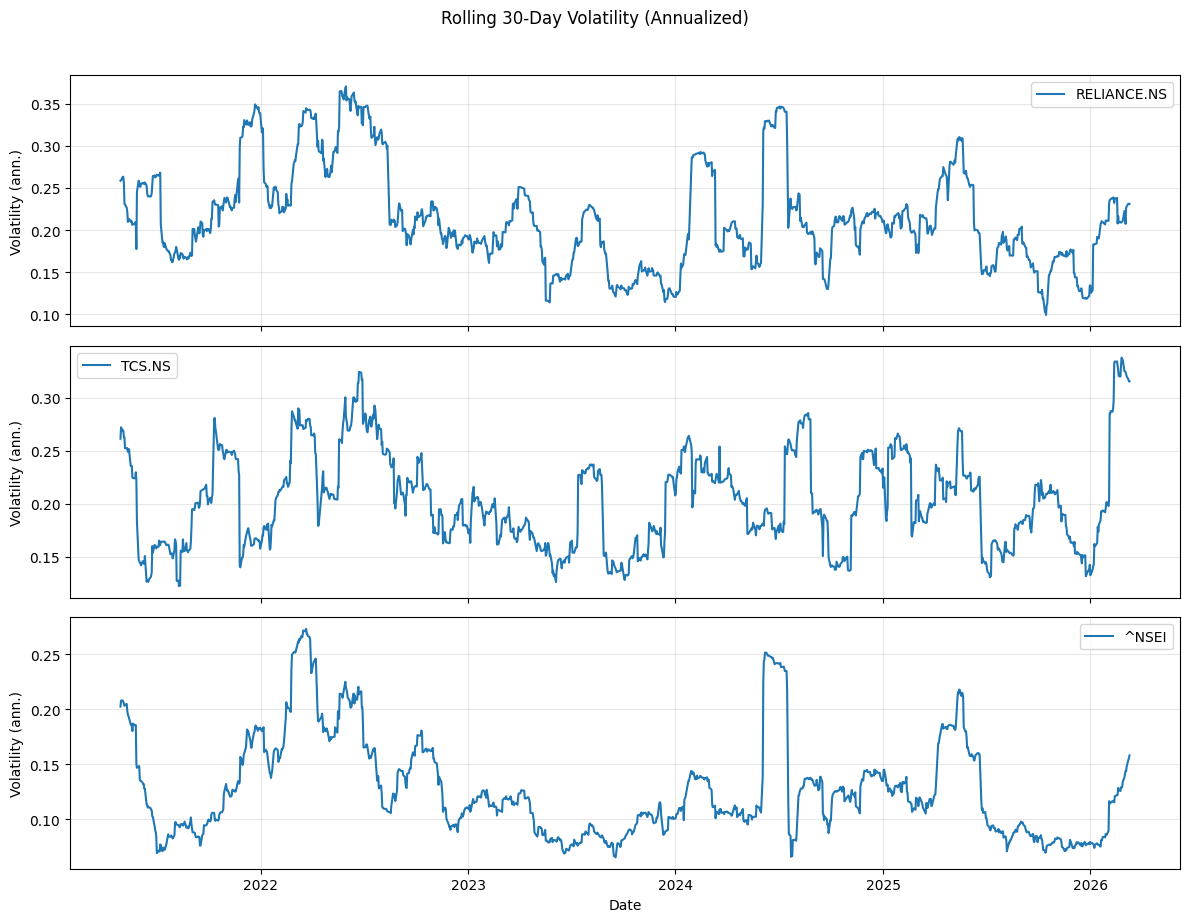

In [42]:
# Rolling 30-day volatility (annualized)
fig, axes = plt.subplots(n_stocks, 1, figsize=(12, 3 * n_stocks), sharex=True)
if n_stocks == 1:
    axes = [axes]
for ax, t in zip(axes, tickers):
    ax.plot(rolling_vol.index, rolling_vol[t], label=t)
    ax.set_ylabel('Volatility (ann.)')
    ax.legend()
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Date')
plt.suptitle('Rolling 30-Day Volatility (Annualized)', y=1.02)
plt.tight_layout()
plt.show()

---
## 8️⃣ Sharpe Ratio

**Sharpe Ratio** = (Return − Risk-free rate) / Volatility — measures risk-adjusted return.

We assume **6% risk-free rate** (annual). Higher Sharpe = better risk-adjusted performance.

In [43]:
risk_free_rate = 0.06  # 6% annual
excess_return = annual_returns - risk_free_rate / 252  # daily excess
sharpe = (annual_returns - risk_free_rate) / vol_annual
print("Sharpe Ratio (risk-free = 6%):")
for t in tickers:
    print(f"  {t}: {sharpe[t]:.3f}")
print("\nBest risk-adjusted (highest Sharpe):", sharpe.idxmax(), f"({sharpe.max():.3f})")

Sharpe Ratio (risk-free = 6%):
  RELIANCE.NS: 0.180
  TCS.NS: -0.260
  ^NSEI: 0.327

Best risk-adjusted (highest Sharpe): ^NSEI (0.327)


---
## 9️⃣ Portfolio Optimization (Monte Carlo Simulation)

- **10,000 random portfolios**: Random weight combinations across selected stocks
- **Expected return & volatility**: From historical mean returns and covariance
- **Sharpe ratio** per portfolio
- **Efficient Frontier**: Best return for each level of risk
- **Maximum Sharpe portfolio**: Weights that maximize Sharpe
- **Minimum volatility portfolio**: Weights that minimize risk
- All **dynamic** based on your selected tickers (exclude index ticker from optimization if present)

In [44]:
# Use only non-index tickers for optimization (optional: exclude tickers starting with ^)
opt_tickers = [t for t in tickers if not t.startswith('^')]
if len(opt_tickers) < 2:
    opt_tickers = tickers[:2] if len(tickers) >= 2 else tickers
ret_data = daily_returns[opt_tickers].dropna()
mean_returns = ret_data.mean() * 252
cov_matrix = ret_data.cov() * 252
n_assets = len(opt_tickers)
n_portfolios = 10000
np.random.seed(42)
results = np.zeros((3 + n_assets, n_portfolios))
for i in range(n_portfolios):
    weights = np.random.random(n_assets)
    weights /= weights.sum()
    port_ret = np.dot(weights, mean_returns)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    port_sharpe = (port_ret - risk_free_rate) / port_vol if port_vol > 0 else 0
    results[0, i] = port_ret
    results[1, i] = port_vol
    results[2, i] = port_sharpe
    results[3:3+n_assets, i] = weights
cols = ['Return', 'Volatility', 'Sharpe'] + opt_tickers
portfolios = pd.DataFrame(results.T, columns=cols)
portfolios.head()

,Return,Volatility,Sharpe,RELIANCE.NS,TCS.NS
0,0.032309,0.178429,-0.155193,0.282618,0.717382
1,0.057652,0.174358,-0.013467,0.550102,0.449898
2,0.052909,0.172994,-0.040991,0.500039,0.499961
3,0.011487,0.200801,-0.241599,0.062843,0.937157
4,0.049035,0.172609,-0.063526,0.459151,0.540849


In [45]:
# Efficient Frontier + Max Sharpe & Min Vol
max_sharpe_idx = portfolios['Sharpe'].idxmax()
min_vol_idx = portfolios['Volatility'].idxmin()
max_sharpe_port = portfolios.loc[max_sharpe_idx]
min_vol_port = portfolios.loc[min_vol_idx]
print("Maximum Sharpe Portfolio Weights:")
for t in opt_tickers:
    print(f"  {t}: {max_sharpe_port[t]:.2%}")
print(f"  Return: {max_sharpe_port['Return']:.2%}, Vol: {max_sharpe_port['Volatility']:.2%}, Sharpe: {max_sharpe_port['Sharpe']:.3f}")
print("\nMinimum Volatility Portfolio Weights:")
for t in opt_tickers:
    print(f"  {t}: {min_vol_port[t]:.2%}")
print(f"  Return: {min_vol_port['Return']:.2%}, Vol: {min_vol_port['Volatility']:.2%}, Sharpe: {min_vol_port['Sharpe']:.3f}")

Maximum Sharpe Portfolio Weights:
  RELIANCE.NS: 99.99%
  TCS.NS: 0.01%
  Return: 10.03%, Vol: 22.36%, Sharpe: 0.180

Minimum Volatility Portfolio Weights:
  RELIANCE.NS: 45.58%
  TCS.NS: 54.42%
  Return: 4.87%, Vol: 17.26%, Sharpe: -0.065


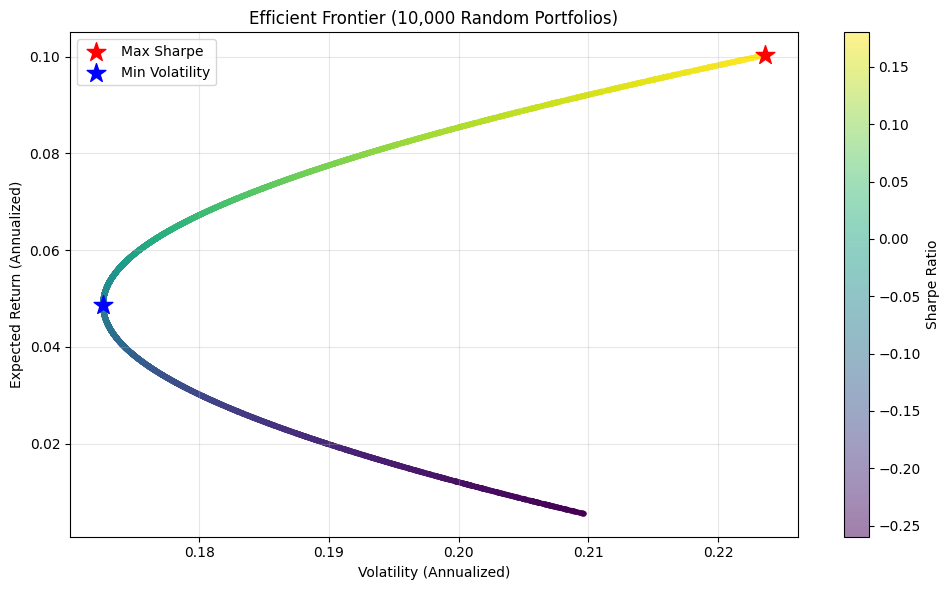

In [46]:
# Plot Efficient Frontier
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(portfolios['Volatility'], portfolios['Return'], c=portfolios['Sharpe'], cmap='viridis', alpha=0.5, s=10)
ax.scatter(max_sharpe_port['Volatility'], max_sharpe_port['Return'], color='red', s=200, marker='*', label='Max Sharpe', zorder=5)
ax.scatter(min_vol_port['Volatility'], min_vol_port['Return'], color='blue', s=200, marker='*', label='Min Volatility', zorder=5)
ax.set_xlabel('Volatility (Annualized)')
ax.set_ylabel('Expected Return (Annualized)')
ax.set_title('Efficient Frontier (10,000 Random Portfolios)')
ax.legend()
plt.colorbar(sc, ax=ax, label='Sharpe Ratio')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 🔟 Investment Growth Simulation

Simulate **₹10,000** (or any amount) invested in:
- Each selected stock (buy-and-hold)
- **Optimized portfolio** (Max Sharpe weights)

Plot cumulative return comparison over the period.

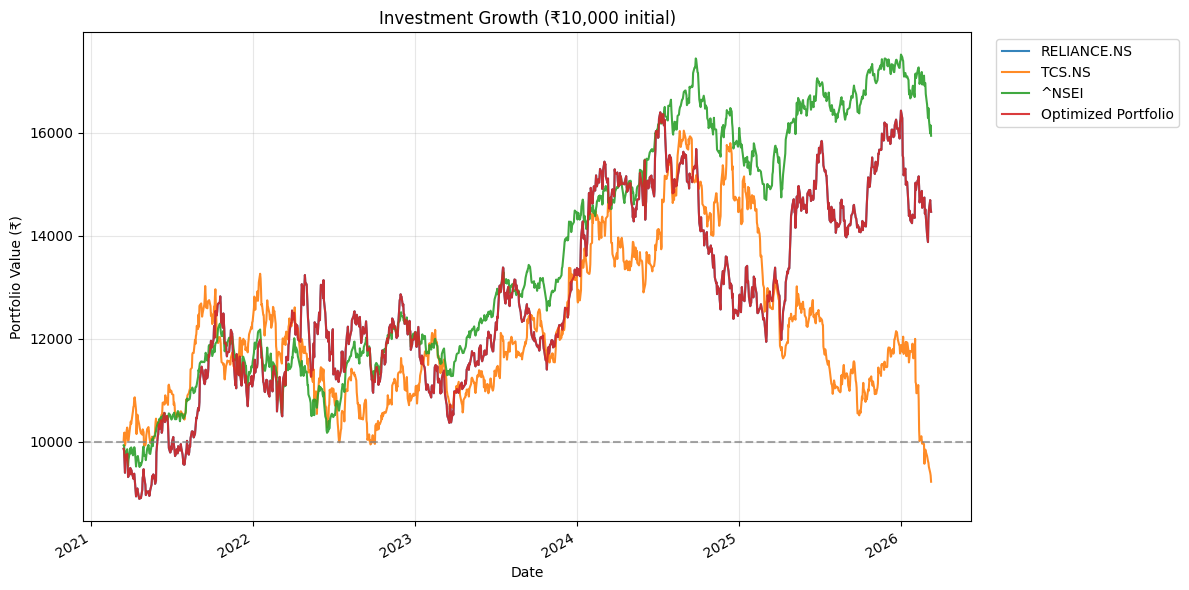

In [47]:
initial_investment = 10000  # ₹10,000
cum_ret = (1 + daily_returns).cumprod()
growth_single = initial_investment * cum_ret
# Optimized portfolio cumulative return (using max Sharpe weights)
opt_weights = max_sharpe_port[opt_tickers].values
port_returns = (daily_returns[opt_tickers] * opt_weights).sum(axis=1)
port_cum = (1 + port_returns).cumprod()
growth_portfolio = initial_investment * port_cum
growth_portfolio.name = 'Optimized Portfolio'
growth_single['Optimized Portfolio'] = growth_portfolio
growth_single.plot(figsize=(12, 6), alpha=0.9)
plt.axhline(initial_investment, color='gray', linestyle='--', alpha=0.7)
plt.ylabel('Portfolio Value (₹)')
plt.xlabel('Date')
plt.title(f'Investment Growth (₹{initial_investment:,} initial)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 💼 Finance Interpretation & Executive Summary

**Executive summary**  
This analysis used **5 years of daily data** for the selected tickers. Returns were annualized and risk metrics (volatility, max drawdown, Beta, Sharpe ratio) were computed. A **Monte Carlo optimization** (10,000 portfolios) identified the maximum-Sharpe and minimum-volatility allocations.

**Risk vs return**  
Stocks with higher historical return typically showed higher volatility and drawdown. The **risk–return trade-off** is evident: no single asset dominates on both dimensions.

**Best risk-adjusted performer**  
The asset with the **highest Sharpe ratio** offers the best excess return per unit of risk (assuming a 6% risk-free rate). This is the preferred choice for risk-aware investors before considering diversification.

**Diversification benefit**  
The **optimized portfolio** (Max Sharpe weights) usually achieves a better Sharpe ratio than individual holdings by combining low-correlated assets, reducing volatility without proportionally reducing return.

**Investor suitability**  
- **Conservative**: Prefer minimum-volatility portfolio or high-Sharpe single asset.  
- **Moderate**: Max Sharpe portfolio.  
- **Aggressive**: Higher allocation to higher-return (and higher-volatility) names, with awareness of drawdown.

*This is for educational and research purposes only; not investment advice.*

In [48]:
# Summary table
summary = pd.DataFrame({
    'Annual Return': annual_returns,
    'Volatility': vol_annual,
    'Sharpe Ratio': sharpe,
    'Max Drawdown': pd.Series(max_dd),
    'CAGR': cagr
})
summary.round(4)

,Annual Return,Volatility,Sharpe Ratio,Max Drawdown,CAGR
RELIANCE.NS,0.1003,0.2236,0.1801,-0.2718,0.0766
TCS.NS,0.0055,0.2097,-0.2598,-0.4248,-0.0160
^NSEI,0.1044,0.1359,0.3267,-0.1723,0.0977


---

## 🚀 Next Steps: Streamlit Web App

For **interactive, real-time analysis** with a polished UI, check out the **Streamlit app** (`app.py`):

```bash
streamlit run app.py
```

### Streamlit App Features (Not in this notebook)

- 🎨 **Professional dark theme** (enforced via `config.toml`)
- 📌 **Badge-style stock selection** with auto-wrapping (handles 10+ stocks gracefully)
- 🔄 **Multi-tab dashboard**: Market Overview, Risk Analytics, Portfolio Optimization, Investment Growth
- ⚡ **Cached computations** for sub-second response times
- 🎯 **Pre-built stock catalogs**: Nifty 50, S&P 500, Nasdaq 100, Dow 30
- 📊 **Sector allocation breakdown** for optimized portfolios
- 🌍 **Deploy anywhere**: Streamlit Cloud, Render, Railway, Docker
- 🔍 **Advanced options**: Log returns toggle, rebalancing backtest, 30-day forecast

### Why Both Interfaces?

| Notebook | Streamlit App |
|----------|---------------|
| ✅ Educational & exploratory | ✅ Production & monitoring |
| ✅ Fully reproducible | ✅ Real-time interactivity |
| ✅ Export for reports | ✅ Share live links |
| ✅ Deep customization | ✅ User-friendly UI |

---
